In [11]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots appear inline in the notebook
%matplotlib inline

# Make plots look cleaner
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = "../data"

print("All imports successful.")

All imports successful.


In [12]:
def parse_fix_file(filepath):
    """
    Reads a bidmc Fix.txt file and extracts age and gender.
    Returns a dict like: {"age": 88, "gender": "M"}
    """
    result = {"age": None, "gender": None}

    with open(filepath, "r") as f:
        text = f.read()

    # Search for "Age: 88" — the \d+ means "one or more digits"
    age_match = re.search(r"Age:\s*(\d+)", text)
    if age_match:
        result["age"] = int(age_match.group(1))

    # Search for "Gender: M" or "Gender: F"
    gender_match = re.search(r"Gender:\s*([MF])", text, re.IGNORECASE)
    if gender_match:
        result["gender"] = gender_match.group(1).upper()

    return result


# Test it on patient 01
fix_data = parse_fix_file(os.path.join(DATA_DIR, "bidmc_01_Fix.txt"))
print("Patient 01 demographics:")
print(f"  Age:    {fix_data['age']}")
print(f"  Gender: {fix_data['gender']}")

Patient 01 demographics:
  Age:    88
  Gender: M


In [13]:
def load_numerics(filepath):
    """
    Loads a single patient's Numerics CSV.
    Cleans column names, handles missing values,
    and removes physiologically impossible readings.
    Returns a cleaned DataFrame.
    """
    df = pd.read_csv(filepath)

    # Strip whitespace from column names
    # ("Time [s]" stays as-is, but any accidental spaces are removed)
    df.columns = df.columns.str.strip()

    # Rename columns to simple, consistent names
    df = df.rename(columns={
        "Time [s]": "time",
        "HR":       "hr",
        "PULSE":    "pulse",
        "RESP":     "rr",
        "SpO2":     "spo2",
    })

    # --- Remove physiologically impossible values ---
    # SpO2 must be between 50% and 100%. Anything outside that is a sensor error.
    if "spo2" in df.columns:
        df.loc[df["spo2"] < 50, "spo2"] = np.nan
        df.loc[df["spo2"] > 100, "spo2"] = np.nan

    # Respiratory rate must be between 3 and 60 breaths/min
    if "rr" in df.columns:
        df.loc[df["rr"] < 3,  "rr"] = np.nan
        df.loc[df["rr"] > 60, "rr"] = np.nan

    # Heart rate must be between 20 and 250 bpm
    if "hr" in df.columns:
        df.loc[df["hr"] < 20,  "hr"] = np.nan
        df.loc[df["hr"] > 250, "hr"] = np.nan

    return df


# Test it
df_test = load_numerics(os.path.join(DATA_DIR, "bidmc_01_Numerics.csv"))

print("Patient 01 after cleaning:")
print(f"  Shape: {df_test.shape}")
print(f"  Columns: {list(df_test.columns)}")
print(f"\n  Missing values:")
print(df_test.isnull().sum().to_string())
print(f"\n  First 5 rows:")
print(df_test.head().to_string())

Patient 01 after cleaning:
  Shape: (481, 5)
  Columns: ['time', 'hr', 'pulse', 'rr', 'spo2']

  Missing values:
time      0
hr        0
pulse    13
rr        0
spo2     13

  First 5 rows:
   time    hr  pulse    rr  spo2
0     0  94.0   93.0  25.0  97.0
1     1  94.0   93.0  25.0  97.0
2     2  94.0   93.0  25.0  97.0
3     3  92.0   93.0  26.0  97.0
4     4  93.0   93.0  26.0  97.0


In [14]:
def extract_features(df_numerics, patient_id, fix_data):
    """
    Takes a single patient's cleaned Numerics DataFrame
    and their demographics, and returns ONE row (a dict)
    summarising the entire recording.
    """
    row = {"patient_id": patient_id}

    # --- SpO2 features ---
    spo2 = df_numerics["spo2"].dropna()  # remove NaN before calculating

    row["spo2_mean"]         = spo2.mean()    # average SpO2 over 8 minutes
    row["spo2_min"]          = spo2.min()     # lowest SpO2 recorded
    row["spo2_std"]          = spo2.std()     # how much it fluctuated
    row["spo2_median"]       = spo2.median()

    # % of time SpO2 was below 95% (mild concern) and below 92% (serious)
    row["spo2_pct_below_95"] = (spo2 < 95).sum() / len(spo2) * 100
    row["spo2_pct_below_92"] = (spo2 < 92).sum() / len(spo2) * 100

    # --- Respiratory rate features ---
    rr = df_numerics["rr"].dropna()

    row["rr_mean"]   = rr.mean()
    row["rr_max"]    = rr.max()
    row["rr_min"]    = rr.min()
    row["rr_std"]    = rr.std()
    row["rr_median"] = rr.median()

    # % of readings outside the normal 12–20 range
    row["rr_pct_abnormal"] = ((rr < 12) | (rr > 20)).sum() / len(rr) * 100

    # % of readings that are tachypnoeic (fast breathing, >25 bpm)
    # This is a clinically important danger sign
    row["rr_pct_above_25"]  = (rr > 25).sum() / len(rr) * 100

    # --- Heart rate features (bonus — helps the model) ---
    hr = df_numerics["hr"].dropna()

    row["hr_mean"] = hr.mean()
    row["hr_std"]  = hr.std()

    # --- Demographics ---
    row["age"]    = fix_data["age"]
    row["gender"] = 1 if fix_data["gender"] == "M" else 0  # M=1, F=0

    return row


# Test on patient 01
features_test = extract_features(
    df_test,
    patient_id="01",
    fix_data=fix_data
)

print("Features for patient 01:")
for key, value in features_test.items():
    if isinstance(value, float):
        print(f"  {key:<25} {value:.2f}")
    else:
        print(f"  {key:<25} {value}")

Features for patient 01:
  patient_id                01
  spo2_mean                 96.92
  spo2_min                  96.00
  spo2_std                  0.36
  spo2_median               97.00
  spo2_pct_below_95         0.00
  spo2_pct_below_92         0.00
  rr_mean                   21.44
  rr_max                    26.00
  rr_min                    20.00
  rr_std                    1.30
  rr_median                 21.00
  rr_pct_abnormal           85.86
  rr_pct_above_25           2.91
  hr_mean                   91.32
  hr_std                    1.01
  age                       88
  gender                    1


In [15]:
all_rows = []
failed_patients = []

for i in range(1, 54):
    patient_id = f"{i:02d}"

    numerics_path = os.path.join(DATA_DIR, f"bidmc_{patient_id}_Numerics.csv")
    fix_path      = os.path.join(DATA_DIR, f"bidmc_{patient_id}_Fix.txt")

    # Skip if files are missing
    if not os.path.exists(numerics_path) or not os.path.exists(fix_path):
        print(f"  ✗ Patient {patient_id}: files missing, skipping")
        failed_patients.append(patient_id)
        continue

    try:
        df_num   = load_numerics(numerics_path)
        fix_data = parse_fix_file(fix_path)
        row      = extract_features(df_num, patient_id, fix_data)
        all_rows.append(row)

    except Exception as e:
        print(f"  ✗ Patient {patient_id}: error — {e}")
        failed_patients.append(patient_id)

# Combine all rows into one DataFrame
df_all = pd.DataFrame(all_rows)

print(f"\n✓ Loaded {len(df_all)} patients successfully")
if failed_patients:
    print(f"✗ Failed: {failed_patients}")

print(f"\nDataset shape: {df_all.shape[0]} rows × {df_all.shape[1]} columns")
print(f"\nFirst 5 rows:")
print(df_all.head().to_string())


✓ Loaded 53 patients successfully

Dataset shape: 53 rows × 18 columns

First 5 rows:
  patient_id  spo2_mean  spo2_min  spo2_std  spo2_median  spo2_pct_below_95  spo2_pct_below_92    rr_mean  rr_max  rr_min    rr_std  rr_median  rr_pct_abnormal  rr_pct_above_25    hr_mean    hr_std   age  gender
0         01  96.916667      96.0  0.357693         97.0                0.0                0.0  21.438669    26.0    20.0  1.296181       21.0        85.862786         2.910603  91.318087  1.012765  88.0       1
1         02  99.989605      99.0  0.101530        100.0                0.0                0.0  15.351351    19.0    14.0  0.934993       15.0         0.000000         0.000000  91.066528  1.440393  65.0       1
2         03  95.750520      95.0  0.619244         96.0                0.0                0.0  17.638254    19.0    16.0  0.767919       18.0         0.000000         0.000000  76.638254  2.142359  46.0       0
3         04  93.000000      92.0  0.250000         93.0         

In [16]:
print("Missing values per column across all 53 patients:")
print(df_all.isnull().sum().to_string())

print(f"\nData types:")
print(df_all.dtypes.to_string())

Missing values per column across all 53 patients:
patient_id           0
spo2_mean            0
spo2_min             0
spo2_std             0
spo2_median          0
spo2_pct_below_95    0
spo2_pct_below_92    0
rr_mean              0
rr_max               0
rr_min               0
rr_std               0
rr_median            0
rr_pct_abnormal      0
rr_pct_above_25      0
hr_mean              0
hr_std               0
age                  1
gender               0

Data types:
patient_id               str
spo2_mean            float64
spo2_min             float64
spo2_std             float64
spo2_median          float64
spo2_pct_below_95    float64
spo2_pct_below_92    float64
rr_mean              float64
rr_max               float64
rr_min               float64
rr_std               float64
rr_median            float64
rr_pct_abnormal      float64
rr_pct_above_25      float64
hr_mean              float64
hr_std               float64
age                  float64
gender                 int64


In [17]:
# Find which patient is missing age
missing_age = df_all[df_all["age"].isnull()]["patient_id"].values
print(f"Patient(s) missing age: {missing_age}")

# Check their Fix.txt manually
for pid in missing_age:
    fix_path = os.path.join(DATA_DIR, f"bidmc_{pid}_Fix.txt")
    with open(fix_path, "r") as f:
        print(f"\nRaw Fix.txt for patient {pid}:")
        print(f.read())

Patient(s) missing age: <StringArray>
['18']
Length: 1, dtype: str

Raw Fix.txt for patient 18:
bidmc_18
Signals: PLETH; RESP; II; V; AVR
Signals sampling frequency: 125 Hz
Numerics: HR; PULSE; RESP; SpO2
Numerics sampling frequency: 1 Hz
Age: NaN
Gender: ?
Location: micu
MIMIC II matched wdb ID: s09483
MIMIC II data segment: 3089-08-26-21-25
Original overall header file: http://physionet.org/physiobank/database/mimic2wdb/matched/s09483/s09483-3089-08-26-21-25.hea
Original signals header file: http://physionet.org/physiobank/database/mimic2wdb/matched/s09483/3192741_0001.hea
Original signals data file: http://physionet.org/physiobank/database/mimic2wdb/matched/s09483/3192741_0001.dat
Original numerics header file: http://physionet.org/physiobank/database/mimic2wdb/matched/s09483/s09483-3089-08-26-21-25n.hea
Original numerics data file: http://physionet.org/physiobank/database/mimic2wdb/matched/s09483/3192741n.dat



In [18]:
# Fill patient 18's missing age with the median age of all other patients
median_age = df_all[df_all["age"].notna()]["age"].median()
df_all["age"] = df_all["age"].fillna(median_age)

# Patient 18 also has Gender: ? which our parser turned into 0 (Female)
# That's wrong — we don't know their gender.
# Re-encode: M=1, F=0, Unknown=-1
# First re-parse gender properly from Fix.txt

def parse_gender(filepath):
    with open(filepath, "r") as f:
        text = f.read()
    match = re.search(r"Gender:\s*([MF?])", text, re.IGNORECASE)
    if not match:
        return -1
    g = match.group(1).upper()
    if g == "M":
        return 1
    elif g == "F":
        return 0
    else:
        return -1   # unknown

# Re-apply gender parsing for all patients now that we handle ?
for i in range(1, 54):
    pid = f"{i:02d}"
    fix_path = os.path.join(DATA_DIR, f"bidmc_{pid}_Fix.txt")
    if not os.path.exists(fix_path):
        continue
    gender_val = parse_gender(fix_path)
    df_all.loc[df_all["patient_id"] == pid, "gender"] = gender_val

print(f"Median age used for patient 18: {median_age:.0f}")
print(f"\nGender distribution after fix:")
print(df_all["gender"].value_counts().sort_index().rename({-1: "Unknown (-1)", 0: "Female (0)", 1: "Male (1)"}))
print(f"\nAny remaining missing values?")
print(df_all.isnull().sum()[df_all.isnull().sum() > 0])
print("None." if df_all.isnull().sum().sum() == 0 else "")

Median age used for patient 18: 68

Gender distribution after fix:
gender
Unknown (-1)     1
Female (0)      32
Male (1)        20
Name: count, dtype: int64

Any remaining missing values?
Series([], dtype: int64)
None.


In [21]:
def assign_risk_label(row):
    """
    Returns 1 (at risk) or 0 (not at risk) for a patient.

    A patient is flagged AT RISK if ANY of the following are true:
      - Mean SpO2 below 95%              (sustained low oxygen)
      - SpO2 dropped below 92% at all    (ever critically low)
      - Mean RR above 20 breaths/min     (persistent tachypnoea)
      - More than 20% of RR readings     (frequently abnormal breathing)
        were outside the 12-20 range
    """
    if pd.isna(row["spo2_mean"]) or pd.isna(row["rr_mean"]):
        return np.nan  # can't label without data

    at_risk = (
        row["spo2_mean"]         < 95  or
        row["spo2_min"]          < 92  or
        row["rr_mean"]           > 20  or
        row["rr_pct_abnormal"]   > 20
    )

    return int(at_risk)


df_all["risk_label"] = df_all.apply(assign_risk_label, axis=1)

# Drop any rows where we couldn't assign a label
df_all = df_all.dropna(subset=["risk_label"])
df_all["risk_label"] = df_all["risk_label"].astype(int)

# Show the distribution
counts = df_all["risk_label"].value_counts().sort_index()
print("Risk label distribution:")
print(f"  Not at risk (0): {counts.get(0, 0)} patients")
print(f"  At risk     (1): {counts.get(1, 0)} patients")
print(f"\n  {counts.get(1, 0) / len(df_all) * 100:.1f}% of patients flagged as at risk")

Risk label distribution:
  Not at risk (0): 32 patients
  At risk     (1): 21 patients

  39.6% of patients flagged as at risk


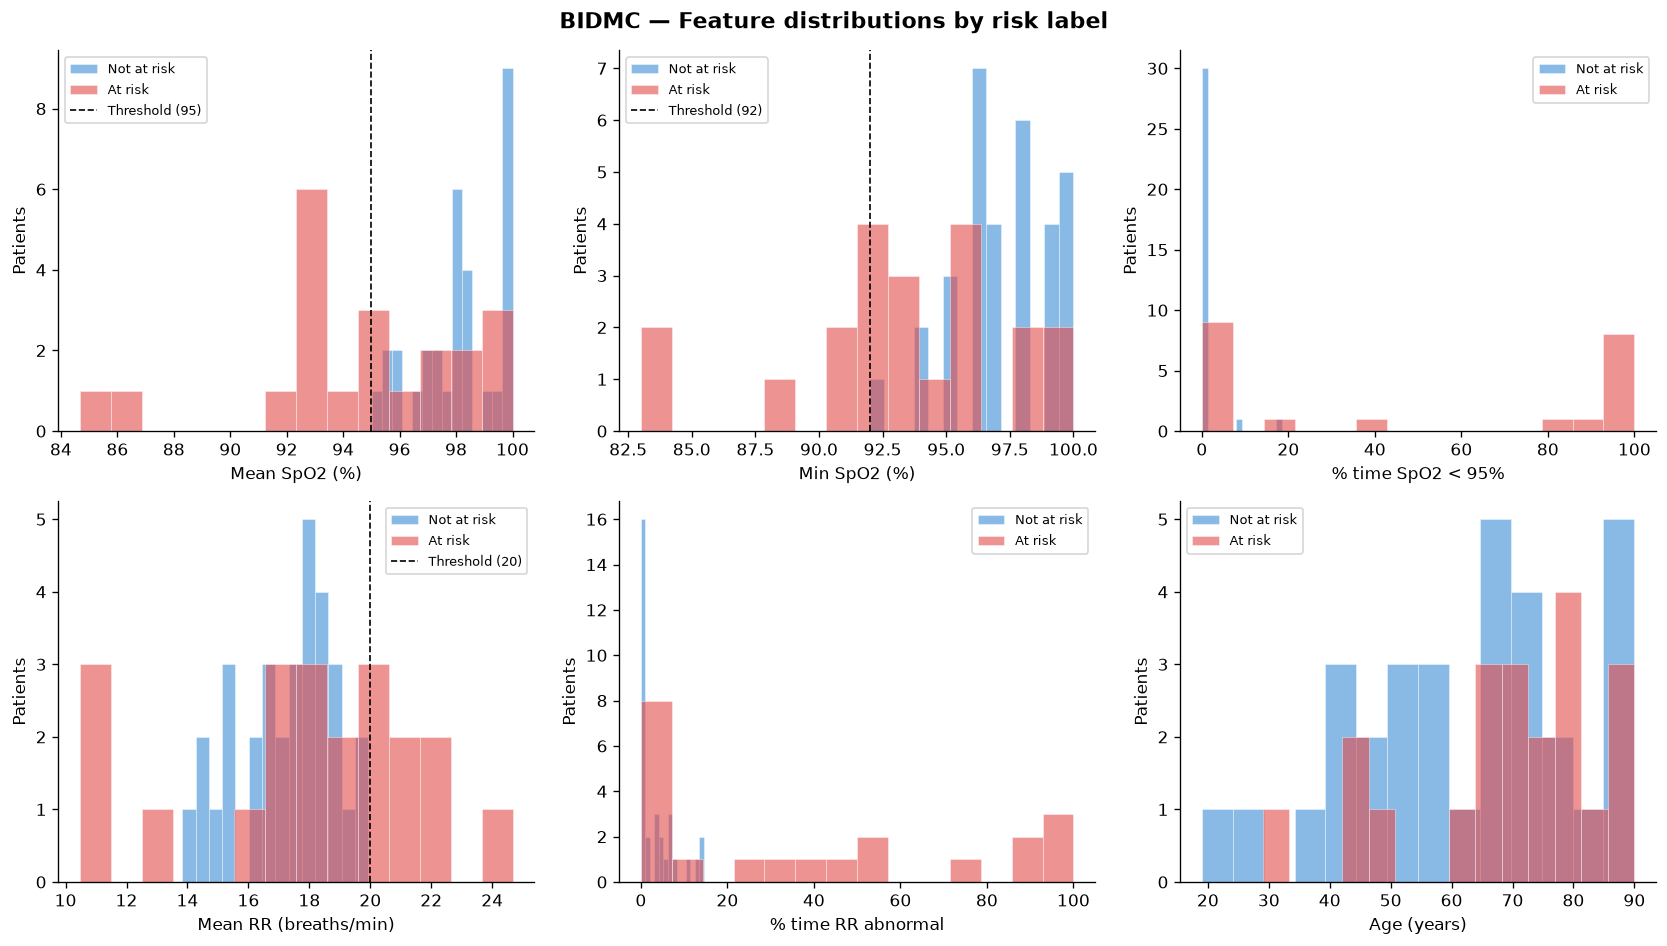

Plot saved to data/feature_distributions.png


In [20]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("BIDMC — Feature distributions by risk label", fontsize=13, fontweight="bold")

colors = {0: "#3B8BD4", 1: "#E24B4A"}
labels = {0: "Not at risk", 1: "At risk"}

# Helper to plot one histogram split by label
def plot_feature(ax, feature, xlabel, threshold=None):
    for label_val in [0, 1]:
        subset = df_all[df_all["risk_label"] == label_val][feature].dropna()
        ax.hist(subset, bins=14, alpha=0.6,
                color=colors[label_val], label=labels[label_val],
                edgecolor="white", linewidth=0.4)
    if threshold is not None:
        ax.axvline(threshold, color="black", linestyle="--",
                   linewidth=1, label=f"Threshold ({threshold})")
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Patients", fontsize=10)
    ax.legend(fontsize=8)

plot_feature(axes[0,0], "spo2_mean",       "Mean SpO2 (%)",           threshold=95)
plot_feature(axes[0,1], "spo2_min",        "Min SpO2 (%)",            threshold=92)
plot_feature(axes[0,2], "spo2_pct_below_95","% time SpO2 < 95%")
plot_feature(axes[1,0], "rr_mean",         "Mean RR (breaths/min)",   threshold=20)
plot_feature(axes[1,1], "rr_pct_abnormal", "% time RR abnormal")
plot_feature(axes[1,2], "age",             "Age (years)")

plt.tight_layout()
plt.savefig("../data/feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to data/feature_distributions.png")

In [22]:
output_path = "../data/features.csv"
df_all.to_csv(output_path, index=False)

print(f"✓ Saved feature table to {output_path}")
print(f"  {df_all.shape[0]} patients × {df_all.shape[1]} columns")
print(f"\nFinal columns:")
for col in df_all.columns:
    print(f"  {col}")

✓ Saved feature table to ../data/features.csv
  53 patients × 19 columns

Final columns:
  patient_id
  spo2_mean
  spo2_min
  spo2_std
  spo2_median
  spo2_pct_below_95
  spo2_pct_below_92
  rr_mean
  rr_max
  rr_min
  rr_std
  rr_median
  rr_pct_abnormal
  rr_pct_above_25
  hr_mean
  hr_std
  age
  gender
  risk_label
